<a href="https://colab.research.google.com/github/nancyngh13-debug/Machine-Learning/blob/main/Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NANCY GALLEGO  15.05.2026 ANALIZANDO CIERRE ACCIÓN NVIDIA

In [9]:
pip install yfinance

In [10]:
# Importar Pandas y Yahoo Finance
import pandas as pd
import yfinance as yf

In [11]:
ticker = "NVDA"
df_nvda = yf.download(ticker, start= "2012-01-01")
df_nvda


/tmp/ipykernel_1627/684028774.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_nvda = yf.download(ticker, start= "2012-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2012-01-03,0.321791,0.330043,0.321104,0.327751,468044000
2012-01-04,0.325459,0.326834,0.319041,0.322021,347372000
2012-01-05,0.337148,0.338752,0.322479,0.323854,563548000
2012-01-06,0.333251,0.337148,0.329355,0.336918,533252000
2012-01-09,0.333251,0.339669,0.330959,0.333480,508244000
...,...,...,...,...,...
2026-05-14,235.740005,236.539993,229.300003,229.850006,180782900
2026-05-15,225.320007,231.500000,224.240005,229.759995,180977600


In [24]:
# Quedarnos únicamente con el valor de cierre
df = df_nvda[('Close', 'NVDA')].to_frame()
df

,Close
,NVDA
Date,
2012-01-03,0.321791
2012-01-04,0.325459
2012-01-05,0.337148
2012-01-06,0.333251
2012-01-09,0.333251
...,...
2026-05-14,235.740005
2026-05-15,225.320007


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3616 entries, 2012-01-03 to 2026-05-20
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, NVDA)  3616 non-null   float64
dtypes: float64(1)
memory usage: 56.5 KB


In [26]:
df.index

DatetimeIndex(['2012-01-03', '2012-01-04', '2012-01-05', '2012-01-06',
               '2012-01-09', '2012-01-10', '2012-01-11', '2012-01-12',
               '2012-01-13', '2012-01-17',
               ...
               '2026-05-07', '2026-05-08', '2026-05-11', '2026-05-12',
               '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-18',
               '2026-05-19', '2026-05-20'],
              dtype='datetime64[ns]', name='Date', length=3616, freq=None)

In [27]:
df.duplicated().any()

np.True_

In [28]:
#Verificar que no se tengan fechas duplicadas en el indice
df.index.duplicated().any()

np.False_

In [29]:
#Verificar faltantes
df.isna().sum()

,,0
Close,NVDA,0


Analisis exploratorio para ver el comportamiento de la serie de tiempo

existe algun patron que nos permita predecir el comportamiento del precio de cierre de la acción de nvidia durante el periodo del año 2012 a la actualidad?

se visualiza una tendencia a el alta en especial apartir de 2024
no se observa comportamiento estacional

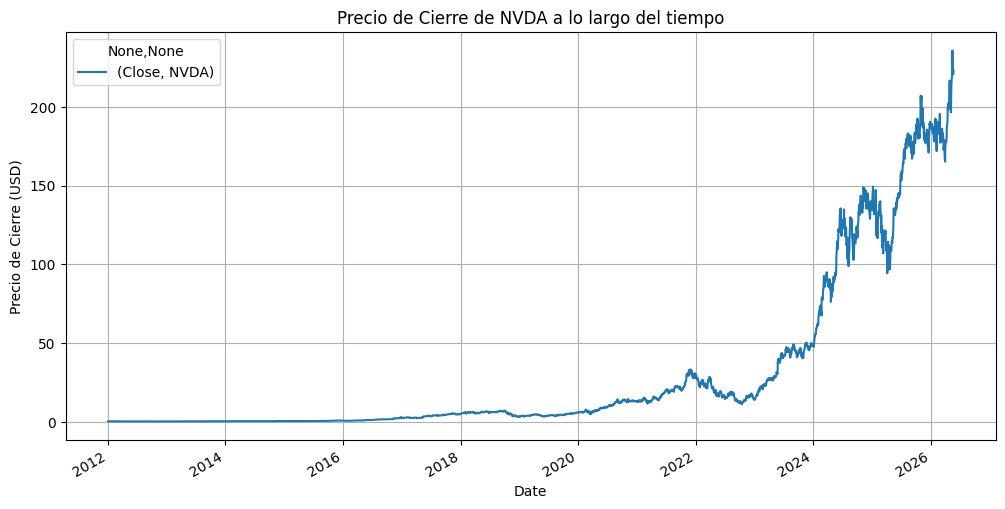

In [32]:
ax = df.plot(figsize=(12,6), title="Precio de Cierre de NVDA a lo largo del tiempo")
ax.grid(True)
ax.set_ylabel("Precio de Cierre (USD)");

In [34]:
df.describe()


,Close_NVDA
count,3616.000000
mean,30.238735
std,52.748456
min,0.260825
25%,0.546926
50%,5.420990
75%,23.361453
max,235.740005


OBSERVACIONES:

-El precio minimo de cierre de la acción es de 0,26(alcanzado a el comienzo dl periodo) y el maximo es de 235,74 (alcanzado durante 2026) esto quiere decir que tuvo una variación de 100*((235,74-0,26)/235,74)=99,89%

-El precio maximo de la acción es de 235 usd que se alcanzo en el año 2026

-La media y la desviación estandar observadas en el periodo analizado

In [38]:
df["media_movil"] = df["Close_NVDA"].rolling(window=365).mean()
df

,Close_NVDA,media_movil
Date,,
2012-01-03,0.321791,NaN
2012-01-04,0.325459,NaN
2012-01-05,0.337148,NaN
2012-01-06,0.333251,NaN
2012-01-09,0.333251,NaN
...,...,...
2026-05-14,235.740005,161.760255
2026-05-15,225.320007,162.006922
2026-05-18,222.320007,162.237401


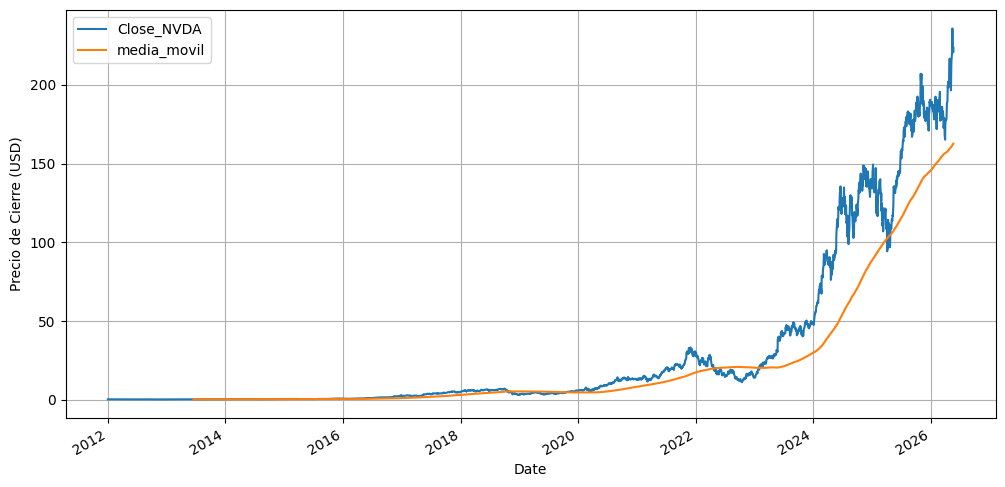

In [43]:
ax = df.plot(figsize=(12,6))
title="Precio de Cierre de NVDA a lo largo del tiempo"
ax.grid(True)
ax.set_ylabel("Precio de Cierre (USD)");

### Descomposición Estacional de la Serie de Tiempo

Podemos descomponer la serie de tiempo del precio de cierre en sus componentes: tendencia, estacionalidad y residuos. Esto nos permite entender mejor los patrones subyacentes.

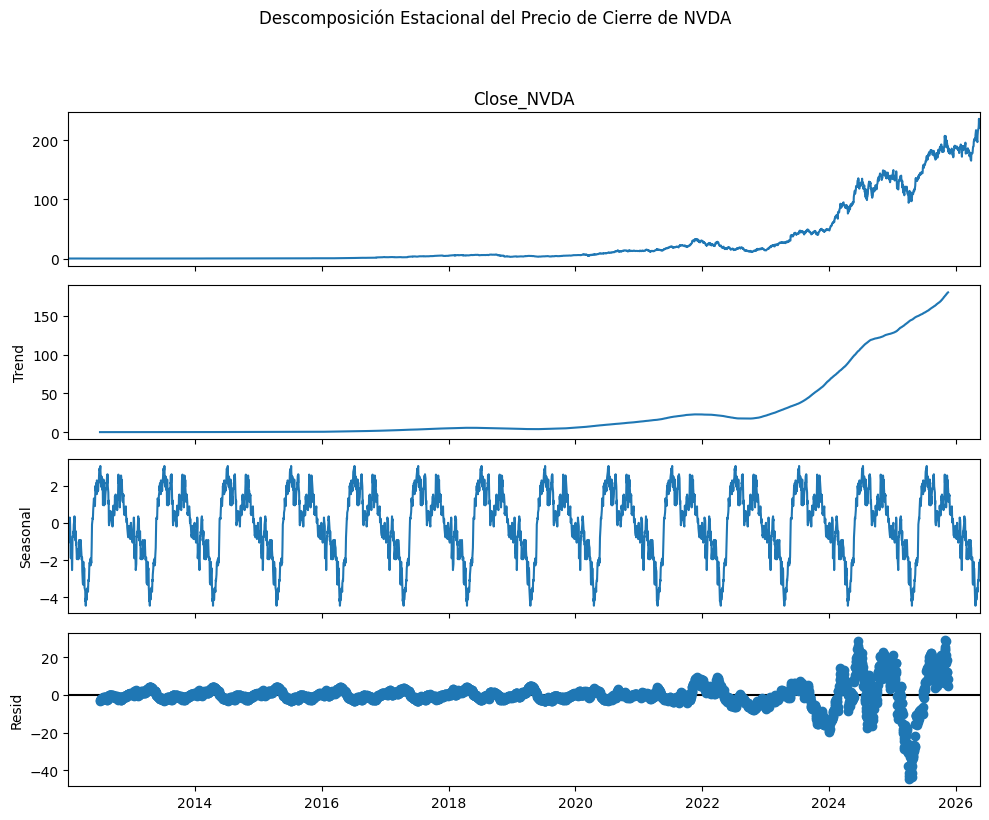

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# La descomposición estacional requiere que el índice sea de tipo DatetimeIndex y que no haya valores nulos.
# Ya hemos verificado que el índice es DatetimeIndex y no hay nulos.
# La frecuencia es importante para la estacionalidad. Como es diaria, podríamos usar 252 para días hábiles en un año, o considerar una estacionalidad semanal (5 días hábiles).
# Para este ejemplo, usaremos una estacionalidad de 252 (días hábiles en un año) si los datos tienen esa longitud,
# o podríamos considerar una estacionalidad de 21 días (aproximadamente un mes laboral) para una vista más granular.
# Sin embargo, para una serie tan larga, `yfinance` a veces puede tener datos irregulares.
# Si la serie de tiempo es muy larga y contiene muchos años, una estacionalidad anual (252 días hábiles) puede ser más apropiada.
# Si vemos que el resultado no es claro, podemos ajustar la frecuencia.

# Establecemos la frecuencia a 'B' (Business Day) para la reindexación y luego a 252 para la descomposición anual.
# Es crucial que la serie no tenga valores duplicados en el índice y que sea una serie univariada.

# Si el índice no tiene frecuencia, la descomposición puede fallar. Establecer una frecuencia.
# df.index = pd.to_datetime(df.index)
# df = df.asfreq('B') # Asegurar que el índice tiene una frecuencia de días hábiles

# Descomposición aditiva (útil cuando las variaciones estacionales son relativamente constantes a lo largo del tiempo)
# Consideraremos una estacionalidad anual para este análisis.
# Si hay muchos años, freq=252 (días hábiles al año) es razonable.
# Si no hay suficiente data para 252, podemos reducir la frecuencia, por ejemplo, a 21 (días hábiles al mes).

# Es importante asegurarse de que la serie no tenga nulos después de la reindexación si se usa.
# Para simplificar y dado que ya se verificó que no hay nulos y el índice es DatetimeIndex continuo,
# procederemos directamente con la descomposición.

# Para usar seasonal_decompose, el índice debe ser un DatetimeIndex con una frecuencia definida, o se puede especificar `period`.
# Ya sabemos que el índice es DatetimeIndex. Establezcamos un período de 252 (días hábiles en un año).

# Renombrar la columna para facilitar el acceso si es un MultiIndex
df.columns = ['Close_NVDA']

# Asegurarse de que el índice es un DatetimeIndex y que no tiene nulos (ya verificados).
# seasonal_decompose puede manejar DatetimeIndex sin una frecuencia explícita si se le pasa 'period'.

# Si hay un error, probamos con una frecuencia menor como 21 (días hábiles en un mes)
# Si los datos no son perfectamente continuos para la frecuencia dada, puede haber problemas.
# Usaremos un período de 252, que representa un año de días hábiles.

# Se necesita un periodo mayor que 1. Si hay menos de 2*period puntos, dará error.
# Con 3616 puntos de datos, 252 es un período adecuado.

# Convertir el DataFrame a una Serie para la descomposición
series_to_decompose = df['Close_NVDA']

# Descomposición aditiva
# Ajustamos `period` a 252 para la estacionalidad anual (días hábiles)
# Si hay gaps o el período no es adecuado, puede fallar o dar resultados extraños.
# Podríamos intentar con `model='multiplicative'` si la estacionalidad varía con la magnitud de la serie.
result = seasonal_decompose(series_to_decompose, model='additive', period=252) # Periodo anual de días hábiles

# Visualizar la descomposición
fig = result.plot()
fig.set_size_inches(10, 8)
plt.suptitle('Descomposición Estacional del Precio de Cierre de NVDA', y=1.02) # Ajustar el título general
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Ajustar diseño para evitar solapamiento del título
plt.show()


### Explicación del Código de Descomposición Estacional

Este código realiza una **descomposición estacional** del precio de cierre de la acción de NVDA, dividiendo la serie de tiempo en varios componentes:

*   `from statsmodels.tsa.seasonal import seasonal_decompose`: Importa la función `seasonal_decompose` de la librería `statsmodels`, que es una herramienta poderosa para el análisis de series de tiempo.
*   `import matplotlib.pyplot as plt`: Importa la librería `matplotlib` para la visualización de los resultados.
*   `df.columns = ['Close_NVDA']`: Renombra la columna del DataFrame `df` de `('Close', 'NVDA')` a `Close_NVDA` para facilitar su manejo. Esto es útil ya que `seasonal_decompose` prefiere trabajar con Series de pandas.
*   `series_to_decompose = df['Close_NVDA']`: Extrae la columna de precios de cierre como una Serie de pandas, que es el formato esperado por `seasonal_decompose`.
*   `result = seasonal_decompose(series_to_decompose, model='additive', period=252)`:
    *   `series_to_decompose`: Es la serie de tiempo que queremos descomponer.
    *   `model='additive'`: Especifica el modelo de descomposición. En un modelo aditivo, se asume que la serie de tiempo es la suma de los componentes (Tendencia + Estacionalidad + Residuo). Un modelo multiplicativo (`model='multiplicative'`) se usaría si la magnitud de los patrones estacionales aumenta con la magnitud de la serie.
    *   `period=252`: Define la longitud del ciclo estacional. En este caso, `252` representa aproximadamente la cantidad de días hábiles en un año, sugiriendo una estacionalidad anual.
*   `fig = result.plot()`: Genera un gráfico con los cuatro componentes de la descomposición: la serie original, la tendencia, la estacionalidad y los residuos.
*   `fig.set_size_inches(10, 8)`: Establece el tamaño de la figura para mejorar la legibilidad.
*   `plt.suptitle(...)`, `plt.tight_layout()` y `plt.show()`: Estas líneas ajustan el título general del gráfico, el diseño de los subgráficos para evitar que se solapen y finalmente muestran el gráfico.

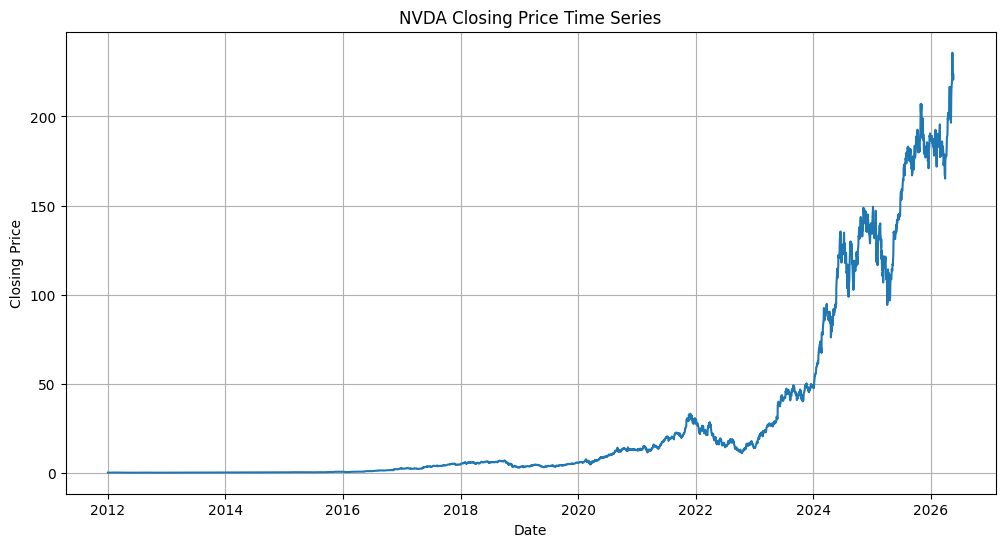

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df.index, df[('Close', 'NVDA')])
plt.title('NVDA Closing Price Time Series')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()